# StutterNet – Base Model Training

We train a **TDNN-based StutterNet** using the **SEP-28k dataset**.
This is the non-optimized version.

```
MyDrive/
└── FluentSpeech/
    ├── clips/
    │  └── {Show}
    │     └── {EpId}
    │        └── {Show}_{EpId}_{ClipId}.wav
    └── SEP-28k_labels.csv
```

In [1]:
# ── 1. Library Installation ──────────────────────────────────────────
!pip install -q librosa scikit-learn tqdm matplotlib onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 51.4 MB/s eta 0:00:00


In [2]:
# ── 2. Google Drive Mount ────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
# ── 3. Imports & Settings ────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from tqdm import tqdm
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# ── Path Settings ──
DRIVE_ROOT      = '/content/drive/MyDrive/26-1_mobicom'
CLIPS_DIR       = os.path.join(DRIVE_ROOT, 'clips')
LABELS_CSV      = os.path.join(DRIVE_ROOT, 'SEP-28k_labels.csv')
CACHE_PATH      = os.path.join(DRIVE_ROOT, 'mfcc_cache.npz')
MODEL_SAVE_PATH = os.path.join(DRIVE_ROOT, 'models', 'stutternet_base.pth')
os.makedirs(os.path.join(DRIVE_ROOT, 'models'), exist_ok=True)

# ── Auto / MFCC Settings ──
SAMPLE_RATE  = 16000
N_MFCC       = 20
HOP_LENGTH   = 160    # 10 ms  @ 16 kHz
WIN_LENGTH   = 400    # 25 ms  @ 16 kHz
N_FFT        = 512
MAX_FRAMES   = 300    # ~3 sec

# ── Training Settings ──
BATCH_SIZE      = 64
EPOCHS          = 30
LR              = 1e-3
WEIGHT_DECAY    = 1e-4
NUM_CLASSES     = 5    # Prolongation, Block, SoundRep, WordRep, Interjection
MAJORITY_VOTE   = 2    # 2 out of 3 agrees → Positive

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'Drive root exists: {os.path.exists(DRIVE_ROOT)}')

Device: cuda
Drive root exists: True


## 1. Data Loading & Label Parsing

In [26]:
# ── 4. Label Parsing ─────────────────────────────────────────────────
STUTTER_COLS = ['Prolongation', 'Block', 'SoundRep', 'WordRep', 'Interjection']
FILTER_COLS  = ['NoSpeech', 'PoorAudioQuality', 'Music']

def find_clip_path(clips_dir, show, ep_id, clip_id):
    path = os.path.join(clips_dir, str(show), str(ep_id), f'{show}_{ep_id}_{clip_id}.wav')
    return path if os.path.exists(path) else None

def load_records(labels_csv, clips_dir, majority_vote=MAJORITY_VOTE):
    df = pd.read_csv(labels_csv)
    print(f'# of rows: {len(df)}')
    print(f'Columns: {list(df.columns)}')

    # Filter out low quality clips
    for col in FILTER_COLS:
        if col in df.columns:
            df = df[df[col] < majority_vote]
    print(f'Quality Filtered: {len(df)}')

    records, missing = [], 0
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Label Parsing'):
        path = find_clip_path(clips_dir, row['Show'], row['EpId'], row['ClipId'])
        if path is None:
            missing += 1
            continue
        labels = [1 if row[col] >= majority_vote else 0 for col in STUTTER_COLS]
        records.append({'path': path, 'labels': labels})

    print(f'Load Success: {len(records)} Clips  |  No Clip: {missing} Clips')
    return records

records = load_records(LABELS_CSV, CLIPS_DIR)

# of rows: 28177
Columns: ['Show', 'EpId', 'ClipId', 'Start', 'Stop', 'Unsure', 'PoorAudioQuality', 'Prolongation', 'Block', 'SoundRep', 'WordRep', 'DifficultToUnderstand', 'Interjection', 'NoStutteredWords', 'NaturalPause', 'Music', 'NoSpeech']
Quality Filtered: 27070


Label Parsing: 100%|██████████| 27070/27070 [00:10<00:00, 2528.65it/s]

Load Success: 20131 Clips  |  No Clip: 6939 Clips


## 2. MFCC Feature Extraction & Caching

In [27]:
# ── 5. MFCC Extraction ───────────────────────────────────────────
def extract_mfcc(path, sr=SAMPLE_RATE, n_mfcc=N_MFCC,
                 hop_length=HOP_LENGTH, win_length=WIN_LENGTH,
                 n_fft=N_FFT, max_frames=MAX_FRAMES):
    try:
        y, _ = librosa.load(path, sr=sr, mono=True)
    except Exception as e:
        return None

    mfcc = librosa.feature.mfcc(
        y=y, sr=sr, n_mfcc=n_mfcc,
        hop_length=hop_length, win_length=win_length, n_fft=n_fft
    ).T  # (time, n_mfcc)

    if mfcc.shape[0] < max_frames:
        pad = np.zeros((max_frames - mfcc.shape[0], n_mfcc))
        mfcc = np.vstack([mfcc, pad])
    else:
        mfcc = mfcc[:max_frames]

    mfcc = (mfcc - mfcc.mean(axis=0)) / (mfcc.std(axis=0) + 1e-8)
    return mfcc.astype(np.float32)


# ── 6. Cache Build & Load ─────────────────────────────────────────
def build_cache(records, cache_path):
    features, all_labels = [], []
    for rec in tqdm(records, desc='MFCC Extraction'):
        feat = extract_mfcc(rec['path'])
        if feat is not None:
            features.append(feat)
            all_labels.append(rec['labels'])

    features   = np.array(features,   dtype=np.float32)
    all_labels = np.array(all_labels, dtype=np.float32)
    np.savez_compressed(cache_path, features=features, labels=all_labels)
    print(f'Cache Storage Success  features={features.shape}  labels={all_labels.shape}')
    return features, all_labels

# Cache remove
print(f'# of Records: {len(records)}')
if os.path.exists(CACHE_PATH):
    try:
      print('Cache load')
      data = np.load(CACHE_PATH)
      features = data['features']
      labels = data['labels']
    except:
      os.remove(CACHE_PATH)
      print('MFCC Extraction...')
      features, labels = build_cache(records, CACHE_PATH)
else:
    print('MFCC Extraction...')
    features, labels = build_cache(records, CACHE_PATH)

# of Records: 20131
Cache load


In [28]:
# ── 7. Class Distribution ────────────────────────────────────────
print('=== Class Distribution (Positive Samples) ===')
for i, col in enumerate(STUTTER_COLS):
    cnt = int(labels[:, i].sum())
    print(f'  {col:<20s}: {cnt:>5d}  ({cnt/len(labels)*100:.1f}%)')

=== Class Distribution (Positive Samples) ===
  Prolongation        :  2001  (9.9%)
  Block               :  2469  (12.3%)
  SoundRep            :  1796  (8.9%)
  WordRep             :  2308  (11.5%)
  Interjection        :  4681  (23.3%)


## 3. Dataset & DataLoader

In [29]:
# ── 8. Dataset ───────────────────────────────────────────
class StutterDataset(Dataset):
    def __init__(self, features, labels):
        self.X = torch.FloatTensor(features)
        self.y = torch.FloatTensor(labels)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# Train / Val / Test Split (80 : 10 : 10)
idx = np.arange(len(features))
train_idx, test_idx  = train_test_split(idx, test_size=0.10, random_state=42)
train_idx, val_idx   = train_test_split(train_idx, test_size=0.11, random_state=42)  # ~10% of total

train_ds = StutterDataset(features[train_idx], labels[train_idx])
val_ds   = StutterDataset(features[val_idx],   labels[val_idx])
test_ds  = StutterDataset(features[test_idx],  labels[test_idx])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds):>5d}')
print(f'Val  : {len(val_ds):>5d}')
print(f'Test : {len(test_ds):>5d}')

Train: 16124
Val  :  1993
Test :  2014


## 4. StutterNet (TDNN) Model

**Sheikh et al. (2021)** :  
`Input(MFCC 20-dim) → TDNN×5 → Statistical Pooling → FC×2 → Output(5 classes)`

In [30]:
# ── 9. TDNN Layer & StutterNet ─────────────────────────────────
class TDNNLayer(nn.Module):
    """1-D Dilated Conv + BN + ReLU (TDNN Single Layer)"""
    def __init__(self, in_dim, out_dim, context_size, dilation=1):
        super().__init__()
        padding = (context_size - 1) * dilation // 2
        self.conv = nn.Conv1d(in_dim, out_dim, kernel_size=context_size,
                              dilation=dilation, padding=padding)
        self.bn   = nn.BatchNorm1d(out_dim)

    def forward(self, x):
        return F.relu(self.bn(self.conv(x)))


class StutterNet(nn.Module):
    """
    StutterNet (TDNN-based) for stuttering event classification.
    Input : (batch, MAX_FRAMES, N_MFCC)
    Output: (batch, NUM_CLASSES)  — raw logits (apply sigmoid for probabilities)
    """
    def __init__(self, input_dim=N_MFCC, num_classes=NUM_CLASSES):
        super().__init__()
        # TDNN Stack
        self.tdnn1 = TDNNLayer(input_dim, 512, context_size=5)  # ±2
        self.tdnn2 = TDNNLayer(512,       512, context_size=5)  # ±2
        self.tdnn3 = TDNNLayer(512,       512, context_size=7)  # ±3
        self.tdnn4 = TDNNLayer(512,       512, context_size=1)  # {0}
        self.tdnn5 = TDNNLayer(512,      1500, context_size=1)  # {0}

        # Statistical Pooling + FC
        self.fc1     = nn.Linear(3000, 512)   # mean(1500) + std(1500)
        self.bn6     = nn.BatchNorm1d(512)
        self.fc2     = nn.Linear(512,  512)
        self.bn7     = nn.BatchNorm1d(512)
        self.output  = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = x.transpose(1, 2)          # (B, F, T)

        x = self.tdnn1(x)
        x = self.tdnn2(x)
        x = self.tdnn3(x)
        x = self.tdnn4(x)
        x = self.tdnn5(x)              # (B, 1500, T')

        # Statistical Pooling
        mean = x.mean(dim=-1)          # (B, 1500)
        std  = x.std(dim=-1)           # (B, 1500)
        x    = torch.cat([mean, std], dim=-1)  # (B, 3000)

        x = F.relu(self.bn6(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn7(self.fc2(x)))
        x = self.dropout(x)
        return self.output(x)


model = StutterNet().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\n# of parameters: {total_params:,}')

StutterNet(
  (tdnn1): TDNNLayer(
    (conv): Conv1d(20, 512, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (tdnn2): TDNNLayer(
    (conv): Conv1d(512, 512, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (tdnn3): TDNNLayer(
    (conv): Conv1d(512, 512, kernel_size=(7,), stride=(1,), padding=(3,))
    (bn): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (tdnn4): TDNNLayer(
    (conv): Conv1d(512, 512, kernel_size=(1,), stride=(1,))
    (bn): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (tdnn5): TDNNLayer(
    (conv): Conv1d(512, 1500, kernel_size=(1,), stride=(1,))
    (bn): BatchNorm1d(1500, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (fc1): Linear(in_features=3000, out_features=512, bias=Tru

## 5. Training

In [31]:
# ── 10. Loss / Optimizer / Scheduler ───────────────────────────
def compute_pos_weight(label_array):
    """pos_weight calculation for class imbalance handling"""
    pos = label_array.sum(axis=0)
    neg = len(label_array) - pos
    # return torch.FloatTensor(neg / (pos + 1e-8))
    weights = neg / (pos + 1e-8)
    weights[2] *= 0.2
    weights[3] *= 0.3
    return torch.FloatTensor(weights)

pos_weight = compute_pos_weight(labels[train_idx]).to(DEVICE)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print('pos_weight:', pos_weight.cpu().numpy().round(2))

pos_weight: [8.96 7.09 2.04 2.36 3.28]


In [32]:
# ── 11. Training / Evaluation Function ────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, threshold=0.5):
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for x, y in loader:
            logits = model(x.to(DEVICE))
            preds  = (torch.sigmoid(logits) > threshold).cpu().numpy()
            preds_all.append(preds)
            labels_all.append(y.numpy())
    preds_all  = np.vstack(preds_all)
    labels_all = np.vstack(labels_all)
    macro_f1   = f1_score(labels_all, preds_all, average='macro', zero_division=0)
    return macro_f1, preds_all, labels_all

In [33]:
# ── 12. Main Training Loop ──────────────────────────────────────────
best_val_f1 = 0.0
history = {'train_loss': [], 'val_f1': []}

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_f1, _, _ = evaluate(model, val_loader)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_f1'].append(val_f1)

    marker = ''
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_f1': val_f1,
            'config': {'input_dim': N_MFCC, 'num_classes': NUM_CLASSES,
                       'max_frames': MAX_FRAMES}
        }, MODEL_SAVE_PATH)
        marker = '  ← best saved'

    print(f'Epoch {epoch:02d}/{EPOCHS}  Loss={train_loss:.4f}  Val F1={val_f1:.4f}{marker}')

Epoch 01/30  Loss=0.8980  Val F1=0.2230  ← best saved
Epoch 02/30  Loss=0.8444  Val F1=0.2110
Epoch 03/30  Loss=0.8146  Val F1=0.2542  ← best saved
Epoch 04/30  Loss=0.7912  Val F1=0.3098  ← best saved
Epoch 05/30  Loss=0.7788  Val F1=0.2724
Epoch 06/30  Loss=0.7665  Val F1=0.3091
Epoch 07/30  Loss=0.7564  Val F1=0.3270  ← best saved
Epoch 08/30  Loss=0.7442  Val F1=0.2966
Epoch 09/30  Loss=0.7357  Val F1=0.3235
Epoch 10/30  Loss=0.7216  Val F1=0.3250
Epoch 11/30  Loss=0.7097  Val F1=0.3068
Epoch 12/30  Loss=0.6937  Val F1=0.3332  ← best saved
Epoch 13/30  Loss=0.6827  Val F1=0.3786  ← best saved
Epoch 14/30  Loss=0.6612  Val F1=0.2900
Epoch 15/30  Loss=0.6429  Val F1=0.3645
Epoch 16/30  Loss=0.6104  Val F1=0.3504
Epoch 17/30  Loss=0.5806  Val F1=0.3741
Epoch 18/30  Loss=0.5421  Val F1=0.3825  ← best saved
Epoch 19/30  Loss=0.5029  Val F1=0.3676
Epoch 20/30  Loss=0.4548  Val F1=0.3704
Epoch 21/30  Loss=0.4039  Val F1=0.3693
Epoch 22/30  Loss=0.3571  Val F1=0.3762
Epoch 23/30  Loss=0.30

## 6. Final Evaluation & Learning Curve

In [34]:
# ── 13. Test Evaluation (Best model) ──────────────────────────────────
ckpt = torch.load(MODEL_SAVE_PATH)
model.load_state_dict(ckpt['model_state_dict'])
print(f"Best epoch: {ckpt['epoch']}  Val F1: {ckpt['val_f1']:.4f}")

test_f1, test_preds, test_labels = evaluate(model, test_loader)
print(f'\n=== Test Set Macro F1: {test_f1:.4f} ===')
print(classification_report(test_labels, test_preds,
                             target_names=STUTTER_COLS, zero_division=0))

from sklearn.metrics import f1_score

print('\n=== Optimal Threshold ===')
best_thresholds = []
for i, col in enumerate(STUTTER_COLS):
    best_t, best_f1 = 0.5, 0.0
    for t in [x * 0.05 for x in range(5, 19)]:  # 0.25 ~ 0.90
        preds = (torch.sigmoid(torch.FloatTensor(
            test_preds[:, i])) > t).numpy()
        f1 = f1_score(test_labels[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    best_thresholds.append(best_t)
    print(f'  {col:<20s}: threshold={best_t:.2f}  F1={best_f1:.4f}')

Best epoch: 27  Val F1: 0.3887

=== Test Set Macro F1: 0.3608 ===
              precision    recall  f1-score   support

Prolongation       0.29      0.44      0.35       189
       Block       0.21      0.26      0.24       231
    SoundRep       0.27      0.27      0.27       185
     WordRep       0.27      0.36      0.31       240
Interjection       0.60      0.69      0.64       465

   micro avg       0.37      0.46      0.41      1310
   macro avg       0.33      0.41      0.36      1310
weighted avg       0.38      0.46      0.41      1310
 samples avg       0.22      0.25      0.22      1310


=== Optimal Threshold ===
  Prolongation        : threshold=0.50  F1=0.3515
  Block               : threshold=0.50  F1=0.2355
  SoundRep            : threshold=0.50  F1=0.2703
  WordRep             : threshold=0.50  F1=0.3074
  Interjection        : threshold=0.50  F1=0.6394


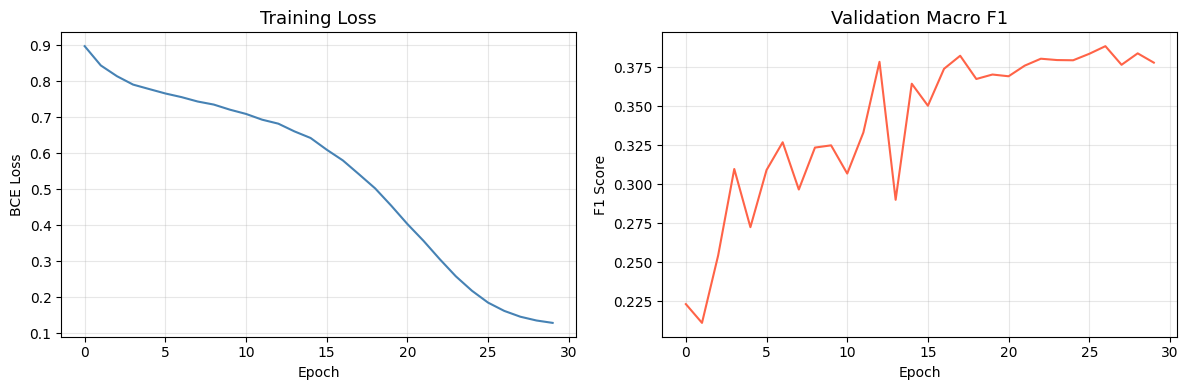

Graph saved


In [35]:
# ── 14. Learning Curve Visualization ────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], color='steelblue')
ax1.set_title('Training Loss', fontsize=13)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
ax1.grid(alpha=0.3)

ax2.plot(history['val_f1'], color='tomato')
ax2.set_title('Validation Macro F1', fontsize=13)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('F1 Score')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_ROOT, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Graph saved')

In [36]:
# ── 15. ONNX Export ──────────────────────────────────────────────
import torch.onnx
import onnx

ONNX_PATH = os.path.join(DRIVE_ROOT, 'models', 'stutternet_base.onnx')

dummy = torch.randn(1, MAX_FRAMES, N_MFCC).to(DEVICE)
model.eval()

torch.onnx.export(
    model, dummy, ONNX_PATH,
    export_params=True,
    opset_version=12,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
    dynamo=False
)

onnx.checker.check_model(onnx.load(ONNX_PATH))
size_mb = os.path.getsize(ONNX_PATH) / (1024**2)
print(f'ONNX Saved')
print(f'Path: {ONNX_PATH}')
print(f'Size: {size_mb:.1f} MB')

ONNX Saved
Path: /content/drive/MyDrive/26-1_mobicom/models/stutternet_base.onnx
Size: 23.0 MB


In [37]:
# ── 16. Model Profiling (Latency / Params / MACs) ────────────────
!pip install -q torchprofile

import time
import torch
from torchprofile import profile_macs

model.eval()
dummy = torch.randn(1, MAX_FRAMES, N_MFCC).to(DEVICE)

# ── 1. Parameters ──────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb    = sum(p.numel() * p.element_size() for p in model.parameters()) / (1024**2)

print('=== Parameters ===')
print(f'  Total     : {total_params:,}')
print(f'  Trainable : {trainable_params:,}')
print(f'  Size      : {model_size_mb:.2f} MB')

# ── 2. MACs ────────────────────────────────────────────────────
macs = profile_macs(model, dummy)
print(f'\n=== MACs ===')
print(f'  MACs      : {macs:,}')
print(f'  GMACs     : {macs / 1e9:.4f} G')

# ── 3. Latency (CPU & GPU) ─────────────────────────────────────
WARMUP = 10
RUNS   = 100

# CPU Latency
model_cpu  = model.cpu()
dummy_cpu  = dummy.cpu()
model_cpu.eval()

for _ in range(WARMUP):
    _ = model_cpu(dummy_cpu)

start = time.perf_counter()
for _ in range(RUNS):
    with torch.no_grad():
        _ = model_cpu(dummy_cpu)
cpu_latency_ms = (time.perf_counter() - start) / RUNS * 1000

print(f'\n=== Latency ===')
print(f'  CPU       : {cpu_latency_ms:.2f} ms  (avg over {RUNS} runs)')

# GPU Latency (사용 가능한 경우)
if torch.cuda.is_available():
    model_gpu  = model.cuda()
    dummy_gpu  = dummy.cuda()
    model_gpu.eval()

    # GPU warmup
    for _ in range(WARMUP):
        _ = model_gpu(dummy_gpu)
    torch.cuda.synchronize()

    starter = torch.cuda.Event(enable_timing=True)
    ender   = torch.cuda.Event(enable_timing=True)
    timings = []

    for _ in range(RUNS):
        starter.record()
        with torch.no_grad():
            _ = model_gpu(dummy_gpu)
        ender.record()
        torch.cuda.synchronize()
        timings.append(starter.elapsed_time(ender))

    gpu_latency_ms = sum(timings) / RUNS
    print(f'  GPU (T4)  : {gpu_latency_ms:.2f} ms  (avg over {RUNS} runs)')
else:
    print(f'  GPU       : N/A')

# ── 요약 ───────────────────────────────────────────────────────
print(f'\n{"="*40}')
print(f'  Params  : {total_params/1e6:.2f} M')
print(f'  MACs    : {macs/1e9:.4f} G')
print(f'  Size    : {model_size_mb:.2f} MB')
print(f'  Latency : {cpu_latency_ms:.2f} ms (CPU)')
if torch.cuda.is_available():
    print(f'            {gpu_latency_ms:.2f} ms (GPU)')
print(f'{"="*40}')

model = model.to(DEVICE)

=== Parameters ===
  Total     : 6,041,497
  Trainable : 6,041,497
  Size      : 23.05 MB

=== MACs ===
  MACs      : 1,270,989,228
  GMACs     : 1.2710 G

=== Latency ===
  CPU       : 31.29 ms  (avg over 100 runs)
  GPU (T4)  : 3.68 ms  (avg over 100 runs)

  Params  : 6.04 M
  MACs    : 1.2710 G
  Size    : 23.05 MB
  Latency : 31.29 ms (CPU)
            3.68 ms (GPU)
